In [1]:
import numpy as np
import matplotlib.pyplot as plt
  
# A - AMPLITUDE - Амплитуда сигнала
# N - Количество отсчетов 
# P - PHASE - Сдвиг фазы задается в градусах
# K - Количество периодов сигнала на графике разбитого на N отсчетов
# Задание характеристик синусоды
S1_A = 5.5
S1_N = 20  
S1_P = 0    
S1_K = 5   

# Задание характеристик косинусоиды
C1_A = 5.5
C1_N = 20  
C1_P = 0   
C1_K = 6     

# Дополнительные сигналы генерируемые на основе синусоиды
W1_A = 5.5
W2_A = 5.5
W3_A = 5.5
W4_A = 5.5

W1_N = 20 
W2_N = 20 
W3_N = 20 
W4_N = 20 

W1_P = 0    
W2_P = 0   
W3_P = 0   
W4_P = 0   

W1_K = 1   
W2_K = 2   
W3_K = 3   
W4_K = 4  

# Генерация сигналов
# S0_i = np.arange(S0_N)
# C0_i = np.arange(C0_N)
# W1_i = np.arange(W1_N)
# W2_i = np.arange(W2_N)
# W3_i = np.arange(W3_N)
# W4_i = np.arange(W4_N)

sin_wave_1 = np.sin(2 * np.pi * S1_K / S1_N)
cos_wave_1 = np.sin(2 * np.pi * C1_K / C1_N)

wave_1 = np.sin(2 * np.pi * W1_K / W1_N)
wave_2 = np.sin(2 * np.pi * W2_K / W2_N)
wave_3 = np.sin(2 * np.pi * W3_K / W3_N)
wave_4 = np.sin(2 * np.pi * W4_K / W4_N)

# Сумма сигналов
sum_wave = wave_1 + wave_2 + wave_3 + wave_4 + sin_wave_1  + cos_wave_1

print(sin_wave_1)
# # Визуализация
# n = np.arange(S1_N)
# # print(sin_wave)
# # print(n)
# plt.figure(figsize=(12, 6))
    
# plt.subplot(2, 1, 1)
# plt.stem(n, sin_wave_1, 'b-', label=f'sin: {S1_N:.3f} циклов/отсчет')
# plt.title('Синусоидальный сигнал')
# plt.xlabel('Номер отсчета (n)')
# plt.ylabel('Амплитуда')
# plt.grid(True)
# plt.legend()


# N = 16  # Число отсчетов
# indices = np.arange(N)  # Ось отсчётов

# # DFT (прямое преобразование Фурье)
# REX = np.zeros(N // 2 + 1)
# IMX = np.zeros(N // 2 + 1)

# for K in range(N // 2 + 1):
#     for I in range(N):
#         angle = 2 * np.pi * K * I / N
#         REX[K] += sum_wave[I] * np.cos(angle)
#         IMX[K] -= sum_wave[I] * np.sin(angle)

1.0


In [2]:
# Импорт необходимых библиотек
import numpy as np
from bokeh.layouts import column, row
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Активируем вывод графиков прямо в Jupyter notebook
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------
N = 15
W1_A = 1.0
W1_P_DEG = 25
W1_K = 1

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------
N_i = np.arange(N)
N_i_half = np.arange(N // 2 + 1)
W1_P_RAD = W1_P_DEG * np.pi / 180

# Генерация сигналов
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
sum_wave = wave_1
F_b = 1

# Прямое дискретное преобразование Фурье (DFT)
REX = np.zeros(N // 2 + 1)
IMX = np.zeros(N // 2 + 1)
sin_k = np.zeros(N)
cos_k = np.zeros(N)

for K in range(N // 2 + 1):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)
        
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)

# Расчет амплитудного спектра
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ----------------------------

# Создание первого графика с настройками для лучшего отображения
p = figure(
    title="Две синусоиды с одинаковой частотой и начальной фазой", 
    width=400,  # Уменьшили ширину
    height=300,  # Уменьшили высоту
    x_axis_label='Отсчеты', 
    y_axis_label='Амплитуда',
    tools="pan,box_zoom,wheel_zoom,reset,save"  # Добавили инструменты для навигации
)

# Отображение данных
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", 
          line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", 
          line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")

# Добавление горизонтальной оси
X_axis = np.zeros(N)
p.line(N_i, X_axis, line_color="black")

# Перемещаем легенду, чтобы она не перекрывала график
p.legend.location = "top_left"
p.legend.background_fill_alpha = 0.5  # Полупрозрачный фон легенды

# Создание второго графика сравнения синусоиды с косинусоидой
p2 = figure(
    title="Сравнение синусоиды с косинусоидой", 
    width=400,  # Уменьшили ширину
    height=300,  # Уменьшили высоту
    x_axis_label='Отсчеты', 
    y_axis_label='Амплитуда',
    x_range=p.x_range,  # Синхронизируем масштаб по X с первым графиком
    y_range=p.y_range,  # Синхронизируем масштаб по Y с первым графиком
    tools="pan,box_zoom,wheel_zoom,reset,save"  # Добавили инструменты для навигации
)

# Отображение данных
p2.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave (синус)", 
          line_color="blue", fill_alpha=0.3)
p2.line(N_i, sum_wave, legend_label="sum_wave (синус)", line_color="blue")

p2.scatter(N_i, cos_k, size=7, marker="diamond", legend_label="cos_k (косинус)", 
          line_color="red", fill_alpha=0.3)
p2.line(N_i, cos_k, legend_label="cos_k (косинус)", line_color="red")

# Добавление горизонтальной оси
p2.line(N_i, X_axis, line_color="black")

# Перемещаем легенду, чтобы она не перекрывала график
p2.legend.location = "top_left"
p2.legend.background_fill_alpha = 0.5  # Полупрозрачный фон легенды

# Создание третьего графика: амплитудный спектр
amp_plot = figure(
    title="Спектр частот", 
    width=800,  # Шире, чтобы занимал всю ширину
    height=300,  # Уменьшили высоту
    x_axis_label='Частота', 
    y_axis_label='Амплитуда',
    tools="pan,box_zoom,wheel_zoom,reset,save"  # Добавили инструменты для навигации
)

# Добавление горизонтальной оси
X_axis_amp = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis_amp, line_color="black")

# Отображение спектра
amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(
    x0=N_i_half, y0=X_axis_amp, x1=N_i_half, y1=amplitude_spectrum, 
    color="navy", alpha=0.6, line_width=2
)

# Компоновка графиков
row_layout = row(p, p2)
layout = column(row_layout, amp_plot)

# Вывод дополнительной информации
print("Сравнение синусоиды с различными фазовыми смещениями")
print(f"Количество точек: {N}")
print(f"Количество периодов: {W1_K}")
print(f"Фаза смещения: {W1_P_DEG}°")
print("Синяя линия - базовая синусоида")
print("Зеленая линия - синусоида на выбранной частоте")
print("Красная линия - косинусоида на выбранной частоте")

# Отображение всех графиков
show(layout)

Loading BokehJS ...

Сравнение синусоиды с различными фазовыми смещениями
Количество точек: 15
Количество периодов: 1
Фаза смещения: 25°
Синяя линия - базовая синусоида
Зеленая линия - синусоида на выбранной частоте
Красная линия - косинусоида на выбранной частоте


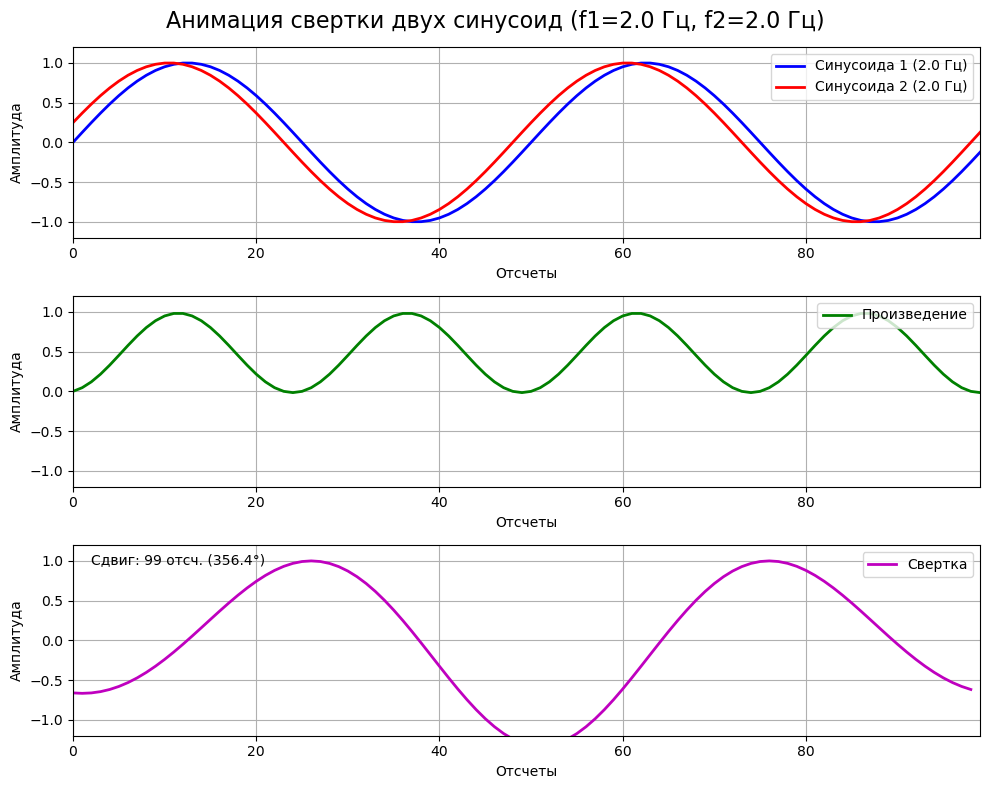

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import signal
import matplotlib.animation as animation

# Параметры сигналов
N = 100  # Количество точек для построения одного периода
t = np.linspace(0, 1, N, endpoint=False)  # Время от 0 до 1 секунды

# Переменные для задания частоты синусоид (в Гц)
freq1 = 2.0  # Частота первой синусоиды
freq2 = 2.0  # Частота второй синусоиды

# Создаем две синусоиды с заданными частотами
sin1 = np.sin(2 * np.pi * freq1 * t)
sin2 = np.sin(2 * np.pi * freq2 * t)

# Вычисляем свертку
convolution = signal.convolve(sin1, sin2, mode='same') / np.sum(sin1)
convolution = convolution / np.max(convolution)  # Нормализуем

# Создаем фигуру и оси
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle(f'Анимация свертки двух синусоид (f1={freq1} Гц, f2={freq2} Гц)', fontsize=16)

# Настраиваем оси - заменяем время на отсчеты
ax1.set_xlim(0, N-1)
ax1.set_ylim(-1.2, 1.2)
ax1.set_ylabel('Амплитуда')
ax1.set_xlabel('Отсчеты')
ax1.grid(True)

ax2.set_xlim(0, N-1)
ax2.set_ylim(-1.2, 1.2)
ax2.set_ylabel('Амплитуда')
ax2.set_xlabel('Отсчеты')
ax2.grid(True)

ax3.set_xlim(0, N-1)
ax3.set_ylim(-1.2, 1.2)
ax3.set_xlabel('Отсчеты')
ax3.set_ylabel('Амплитуда')
ax3.grid(True)

# Создаем пустые графики
line1, = ax1.plot([], [], 'b-', linewidth=2, label=f'Синусоида 1 ({freq1} Гц)')
line2, = ax1.plot([], [], 'r-', linewidth=2, label=f'Синусоида 2 ({freq2} Гц)')
line3, = ax2.plot([], [], 'g-', linewidth=2, label='Произведение')
line4, = ax3.plot([], [], 'm-', linewidth=2, label='Свертка')

# Добавляем легенды
ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')

# Добавляем текст для отображения текущего сдвига в отсчетах и градусах
text = ax3.text(0.02, 0.9, '', transform=ax3.transAxes)

# Функция инициализации
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    text.set_text('')
    return line1, line2, line3, line4, text

# Функция анимации
def animate(i):
    # Создаем массив отсчетов
    samples = np.arange(N)
    
    # Сдвигаем вторую синусоиду
    shift = i  # сдвиг в отсчетах
    phase_shift = (i / N) * 360  # сдвиг в градусах
    sin2_shifted = np.sin(2 * np.pi * freq2 * (t - i/N))
    sin2_shifted = np.roll(sin2_shifted, i)
    
    # Вычисляем произведение в каждой точке
    product = sin1 * sin2_shifted
    
    # Вычисляем частичную свертку (интеграл произведения)
    partial_conv = np.zeros_like(convolution)
    if i > 0:
        partial_conv[:i] = convolution[:i]
    
    # Обновляем графики - используем отсчеты вместо времени
    line1.set_data(samples, sin1)
    line2.set_data(samples, sin2_shifted)
    line3.set_data(samples, product)
    line4.set_data(samples[:i], partial_conv[:i])
    
    # Обновляем текст - добавляем информацию о сдвиге в отсчетах и градусах
    text.set_text(f'Сдвиг: {shift} отсч. ({phase_shift:.1f}°)')
    
    return line1, line2, line3, line4, text

# Создаем анимацию
ani = FuncAnimation(fig, animate, frames=N, init_func=init, 
                    blit=True, interval=50, repeat=True)

# Сохраняем анимацию как GIF
fps_value = 10  # Скорость анимации
ani.save('convolution_animation.gif', writer='pillow', fps=fps_value)

plt.tight_layout()
plt.show()

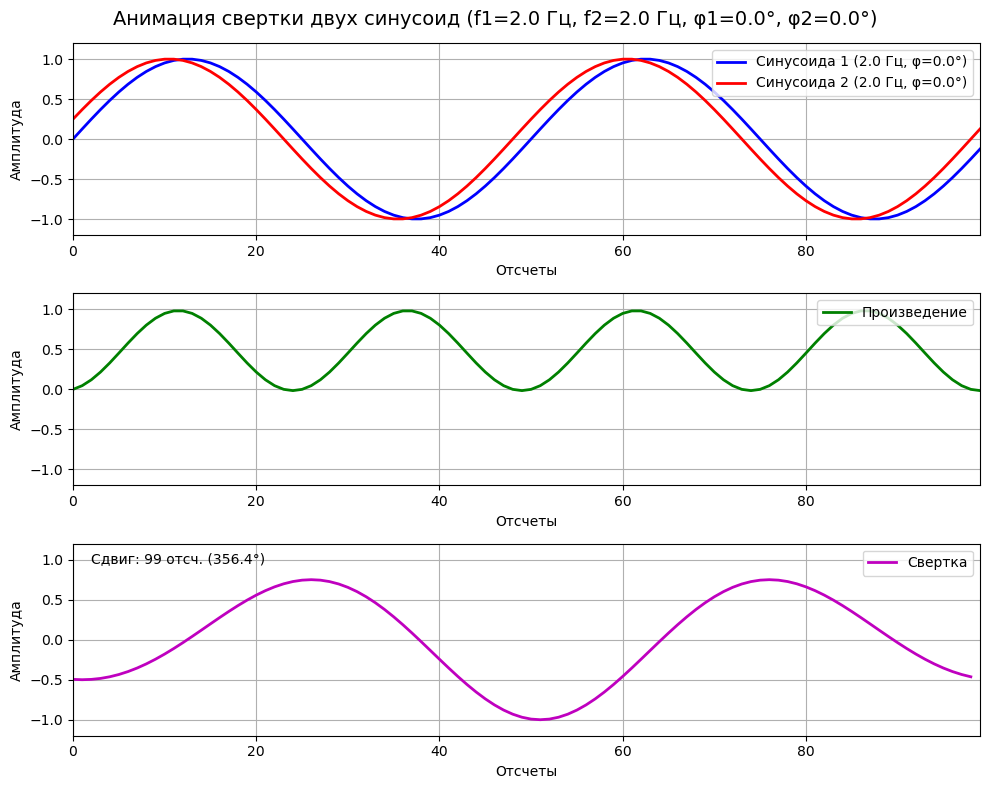

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import signal
import matplotlib.animation as animation

# Параметры сигналов
N = 100  # Количество точек для построения одного периода
t = np.linspace(0, 1, N, endpoint=False)  # Время от 0 до 1 секунды

fps_value = 1  # Скорость анимации
# Переменные для задания частоты синусоид (в Гц)
freq1 = 2.0  # Частота первой синусоиды
freq2 = 2.0  # Частота второй синусоиды

# Переменные для задания начальных фаз синусоид (в градусах)
phase1_deg = 0.0  # Начальная фаза первой синусоиды
phase2_deg = 0.0  # Начальная фаза второй синусоиды

# Преобразование фаз из градусов в радианы
phase1_rad = phase1_deg * np.pi / 180
phase2_rad = phase2_deg * np.pi / 180

# Создаем две синусоиды с заданными частотами и фазами
sin1 = np.sin(2 * np.pi * freq1 * t + phase1_rad)
sin2 = np.sin(2 * np.pi * freq2 * t + phase2_rad)

# Вычисляем свертку
convolution = signal.convolve(sin1, sin2, mode='same') / np.sum(sin1)
convolution = convolution / np.max(np.abs(convolution))  # Нормализуем по максимуму абсолютного значения

# Находим границы для осей Y
y_min = min(np.min(sin1), np.min(sin2), np.min(convolution), -1.0)
y_max = max(np.max(sin1), np.max(sin2), np.max(convolution), 1.0)

# Добавляем небольшой запас по вертикали
y_range = y_max - y_min
y_min -= y_range * 0.1
y_max += y_range * 0.1

# Создаем фигуру и оси
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle(f'Анимация свертки двух синусоид (f1={freq1} Гц, f2={freq2} Гц, φ1={phase1_deg}°, φ2={phase2_deg}°)', fontsize=14)

# Настраиваем оси - заменяем время на отсчеты
ax1.set_xlim(0, N-1)
ax1.set_ylim(y_min, y_max)
ax1.set_ylabel('Амплитуда')
ax1.set_xlabel('Отсчеты')
ax1.grid(True)

ax2.set_xlim(0, N-1)
ax2.set_ylim(y_min, y_max)
ax2.set_ylabel('Амплитуда')
ax2.set_xlabel('Отсчеты')
ax2.grid(True)

ax3.set_xlim(0, N-1)
ax3.set_ylim(y_min, y_max)
ax3.set_xlabel('Отсчеты')
ax3.set_ylabel('Амплитуда')
ax3.grid(True)

# Создаем пустые графики
line1, = ax1.plot([], [], 'b-', linewidth=2, label=f'Синусоида 1 ({freq1} Гц, φ={phase1_deg}°)')
line2, = ax1.plot([], [], 'r-', linewidth=2, label=f'Синусоида 2 ({freq2} Гц, φ={phase2_deg}°)')
line3, = ax2.plot([], [], 'g-', linewidth=2, label='Произведение')
line4, = ax3.plot([], [], 'm-', linewidth=2, label='Свертка')

# Добавляем легенды
ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')

# Добавляем текст для отображения текущего сдвига в отсчетах и градусах
text = ax3.text(0.02, 0.9, '', transform=ax3.transAxes)

# Функция инициализации
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    text.set_text('')
    return line1, line2, line3, line4, text

# Функция анимации
def animate(i):
    # Создаем массив отсчетов
    samples = np.arange(N)
    
    # Сдвигаем вторую синусоиду
    shift = i  # сдвиг в отсчетах
    phase_shift = (i / N) * 360  # сдвиг в градусах
    sin2_shifted = np.sin(2 * np.pi * freq2 * (t - i/N) + phase2_rad)
    sin2_shifted = np.roll(sin2_shifted, i)
    
    # Вычисляем произведение в каждой точке
    product = sin1 * sin2_shifted
    
    # Вычисляем частичную свертку (интеграл произведения)
    partial_conv = np.zeros_like(convolution)
    if i > 0:
        partial_conv[:i] = convolution[:i]
    
    # Обновляем графики - используем отсчеты вместо времени
    line1.set_data(samples, sin1)
    line2.set_data(samples, sin2_shifted)
    line3.set_data(samples, product)
    line4.set_data(samples[:i], partial_conv[:i])
    
    # Обновляем текст - добавляем информацию о сдвиге в отсчетах и градусах
    text.set_text(f'Сдвиг: {shift} отсч. ({phase_shift:.1f}°)')
    
    return line1, line2, line3, line4, text

# Создаем анимацию
ani = FuncAnimation(fig, animate, frames=N, init_func=init, 
                    blit=True, interval=50, repeat=True)

# Сохраняем анимацию как GIF

ani.save('convolution_animation.gif', writer='pillow', fps=fps_value)

plt.tight_layout()
plt.show()

Loading BokehJS ...

Фаза: 0°, REX[1] = 0.00000
Фаза: 0°, REX[1] = 0.00000
Фаза: 5°, REX[1] = 0.69725
Фаза: 10°, REX[1] = 1.38919
Фаза: 15°, REX[1] = 2.07055
Фаза: 20°, REX[1] = 2.73616
Фаза: 25°, REX[1] = 3.38095
Фаза: 30°, REX[1] = 4.00000
Фаза: 35°, REX[1] = 4.58861
Фаза: 40°, REX[1] = 5.14230
Фаза: 45°, REX[1] = 5.65685
Фаза: 50°, REX[1] = 6.12836
Фаза: 55°, REX[1] = 6.55322
Фаза: 60°, REX[1] = 6.92820
Фаза: 65°, REX[1] = 7.25046
Фаза: 70°, REX[1] = 7.51754
Фаза: 75°, REX[1] = 7.72741
Фаза: 80°, REX[1] = 7.87846
Фаза: 85°, REX[1] = 7.96956
Фаза: 90°, REX[1] = 8.00000
Фаза: 95°, REX[1] = 7.96956
Фаза: 100°, REX[1] = 7.87846
Фаза: 105°, REX[1] = 7.72741
Фаза: 110°, REX[1] = 7.51754
Фаза: 115°, REX[1] = 7.25046
Фаза: 120°, REX[1] = 6.92820
Фаза: 125°, REX[1] = 6.55322
Фаза: 130°, REX[1] = 6.12836
Фаза: 135°, REX[1] = 5.65685
Фаза: 140°, REX[1] = 5.14230
Фаза: 145°, REX[1] = 4.58861
Фаза: 150°, REX[1] = 4.00000
Фаза: 155°, REX[1] = 3.38095
Фаза: 160°, REX[1] = 2.73616
Фаза: 165°, REX[1] = 2.07055
Фаза: 170

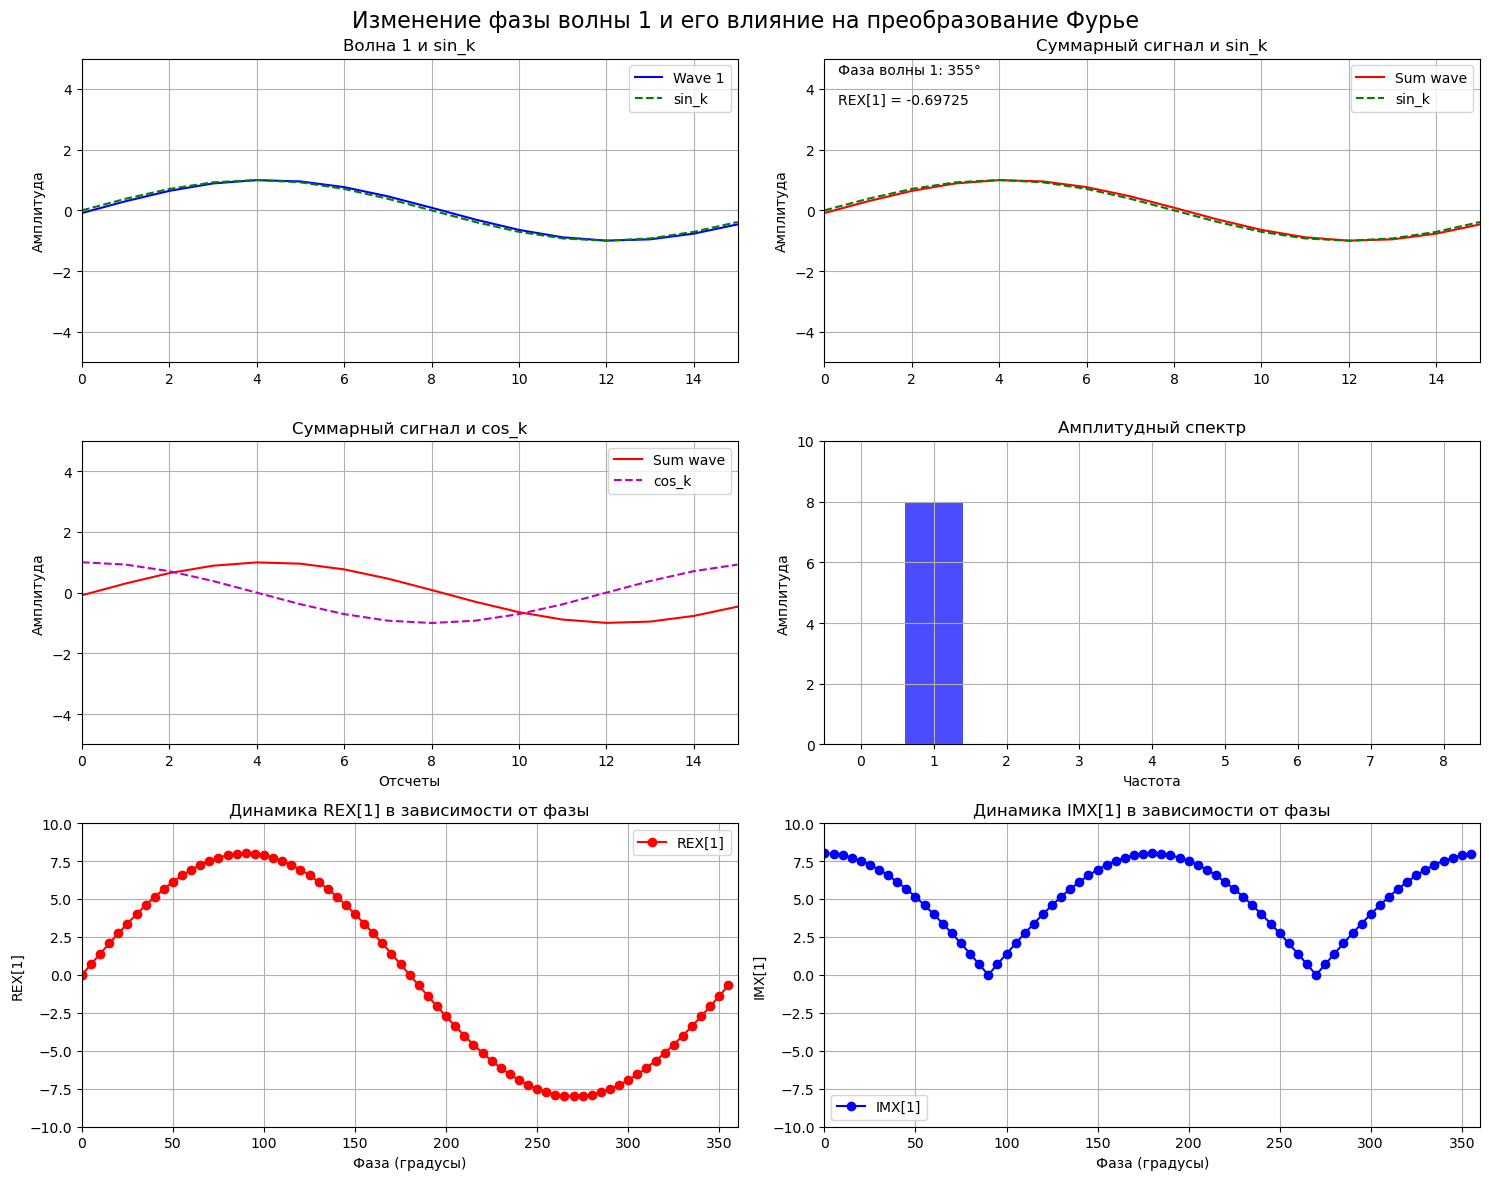

Фаза: 45°, REX[1] = 5.65685


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import matplotlib.animation as animation

# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 16  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 2.0  # Амплитуда дополнительной волны 2
W3_A = 3.0  # Амплитуда дополнительной волны 3
W4_A = 4.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 45   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0 # Дополнительная волна 4

# Выбранная частота для анализа
F_b = 1

# ----------------------------
# ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЙ
# ----------------------------

def compute_signals(phase_deg):
    # Конвертация фаз из градусов в радианы
    W1_P_RAD = phase_deg * np.pi / 180
    W2_P_RAD = W2_P_DEG * np.pi / 180
    W3_P_RAD = W3_P_DEG * np.pi / 180
    W4_P_RAD = W4_P_DEG * np.pi / 180

    # Генерация волн
    wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
    wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
    wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
    wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

    # Сумма сигналов
    sum_wave = wave_1 + wave_2 + wave_3 + wave_4

    # DFT (прямое преобразование Фурье)
    REX = np.zeros(N // 2 + 1)
    IMX = np.zeros(N // 2 + 1)
    sin_k = np.zeros(N)
    cos_k = np.zeros(N)

    # Переменная для хранения значений REX[K] для выбранного F_b
    rex_values = []
    
    for K in range(N // 2 + 1):
        for I in range(N):
            angle = 2 * np.pi * K * I / N
            REX[K] += sum_wave[I] * np.cos(angle)
            IMX[K] -= sum_wave[I] * np.sin(angle)

            if K == F_b:
                cos_k[I] = np.cos(angle)
                sin_k[I] = np.sin(angle)
                rex_values.append(REX[K])  # Сохраняем текущее значение REX[K]
                
                # Вывод информации о вычислениях
                if I == N-1:  # Выводим только для последнего отсчета
                    print(f"Фаза: {phase_deg}°, REX[{F_b}] = {REX[F_b]:.5f}")

    # Амплитудный спектр
    amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
    
    return wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, REX[F_b]

# ----------------------------
# ПОДГОТОВКА ДАННЫХ ДЛЯ АНИМАЦИИ
# ----------------------------

# Создаем массив отсчетов
N_i = np.arange(N)
N_i_half = np.arange(N // 2 + 1)

# Создаем фигуру для анимации с дополнительным графиком
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Изменение фазы волны 1 и его влияние на преобразование Фурье', fontsize=16)

# Настраиваем оси для первых четырех графиков
for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True)
    ax.set_xlim(0, N-1)
    ax.set_ylim(-5, 5)

ax1.set_ylabel('Амплитуда')
ax1.set_title('Волна 1 и sin_k')

ax2.set_ylabel('Амплитуда')
ax2.set_title('Суммарный сигнал и sin_k')

ax3.set_ylabel('Амплитуда')
ax3.set_xlabel('Отсчеты')
ax3.set_title('Суммарный сигнал и cos_k')

# Настраиваем ось для спектра
ax4.grid(True)
ax4.set_xlim(-0.5, len(N_i_half)-0.5)
ax4.set_ylim(0, 10)
ax4.set_ylabel('Амплитуда')
ax4.set_xlabel('Частота')
ax4.set_title('Амплитудный спектр')

# Настраиваем ось для графика REX[1]
ax5.grid(True)
ax5.set_xlim(0, 360)
ax5.set_ylim(-10, 10)
ax5.set_ylabel('REX[1]')
ax5.set_xlabel('Фаза (градусы)')
ax5.set_title('Динамика REX[1] в зависимости от фазы')

# Настраиваем ось для графика IMX[1]
ax6.grid(True)
ax6.set_xlim(0, 360)
ax6.set_ylim(-10, 10)
ax6.set_ylabel('IMX[1]')
ax6.set_xlabel('Фаза (градусы)')
ax6.set_title('Динамика IMX[1] в зависимости от фазы')

# Создаем пустые графики
line1, = ax1.plot([], [], 'b-', label='Wave 1')
line1_sin, = ax1.plot([], [], 'g--', label='sin_k')
line2, = ax2.plot([], [], 'r-', label='Sum wave')
line2_sin, = ax2.plot([], [], 'g--', label='sin_k')
line3, = ax3.plot([], [], 'r-', label='Sum wave')
line3_cos, = ax3.plot([], [], 'm--', label='cos_k')

# Для спектра создаем пустой bar-plot вместо stem-plot
bars = ax4.bar(N_i_half, np.zeros_like(N_i_half), width=0.8, color='blue', alpha=0.7)

# Для графиков REX[1] и IMX[1] создаем пустые линии
line_rex, = ax5.plot([], [], 'ro-', label='REX[1]')
line_imx, = ax6.plot([], [], 'bo-', label='IMX[1]')

# Добавляем легенды
ax1.legend()
ax2.legend()
ax3.legend()
ax5.legend()
ax6.legend()

# Добавляем текст для отображения фазы и значения REX[K]
phase_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes)
rex_text = ax2.text(0.02, 0.85, '', transform=ax2.transAxes)

# Списки для хранения истории значений
phases_history = []
rex_history = []
imx_history = []

# ----------------------------
# ФУНКЦИЯ АНИМАЦИИ
# ----------------------------

def animate(phase_idx):
    # Вычисляем текущую фазу (от 0 до 360 градусов с шагом 5)
    phase_deg = phase_idx * 5
    
    # Вычисляем сигналы для текущей фазы
    wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb = compute_signals(phase_deg)
    
    # Сохраняем текущие значения для истории
    phases_history.append(phase_deg)
    rex_history.append(rex_fb)
    
    # Вычисляем IMX[F_b] для текущей фазы
    # Для этого нам нужно модифицировать compute_signals, чтобы она возвращала также IMX[F_b]
    # Пока что используем приближенное значение
    imx_fb = np.sqrt(amplitude_spectrum[F_b]**2 - rex_fb**2)
    imx_history.append(imx_fb)
    
    # Обновляем графики
    line1.set_data(N_i, wave_1)
    line1_sin.set_data(N_i, sin_k)
    line2.set_data(N_i, sum_wave)
    line2_sin.set_data(N_i, sin_k)
    line3.set_data(N_i, sum_wave)
    line3_cos.set_data(N_i, cos_k)
    
    # Обновляем спектр (bar-plot)
    for i, bar in enumerate(bars):
        if i < len(amplitude_spectrum):
            bar.set_height(amplitude_spectrum[i])
        else:
            bar.set_height(0)
    
    # Обновляем графики REX[1] и IMX[1]
    line_rex.set_data(phases_history, rex_history)
    line_imx.set_data(phases_history, imx_history)
    
    # Автоматически масштабируем оси для графиков REX[1] и IMX[1]
    ax5.relim()
    ax5.autoscale_view()
    ax6.relim()
    ax6.autoscale_view()
    
    # Обновляем текст
    phase_text.set_text(f'Фаза волны 1: {phase_deg}°')
    rex_text.set_text(f'REX[{F_b}] = {rex_fb:.5f}')
    
    return line1, line1_sin, line2, line2_sin, line3, line3_cos, bars, line_rex, line_imx, phase_text, rex_text

# ----------------------------
# СОЗДАНИЕ АНИМАЦИИ
# ----------------------------

# Создаем анимацию (72 кадра - 360 градусов / 5 градусов)
ani = FuncAnimation(fig, animate, frames=72, interval=100, blit=False, repeat=False)

# Сохраняем анимацию как GIF
ani.save('phase_animation.gif', writer='pillow', fps=1)

plt.tight_layout()
plt.show()

# ----------------------------
# ВЫВОД СТАТИЧЕСКИХ ГРАФИКОВ ДЛЯ ТЕКУЩЕЙ ФАЗЫ
# ----------------------------

# Вычисляем сигналы для начальной фазы
wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb = compute_signals(W1_P_DEG)

# Создаем графики с помощью Bokeh
p = figure(title="Суммарный сигнал и sin_k", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")
p.line(N_i, np.zeros(N), line_color="black")
show(p)

p2 = figure(title="Суммарный сигнал и cos_k", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p2.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p2.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p2.scatter(N_i, cos_k, size=7, marker="square", legend_label="cos_k", line_color="green", fill_alpha=0.3)
p2.line(N_i, cos_k, legend_label="cos_k", line_color="green")
p2.line(N_i, np.zeros(N), line_color="black")
show(p2)

amp_plot = figure(title="Амплитудный спектр", x_axis_label='Частота', y_axis_label='Амплитуда')
X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")
amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0=N_i_half, y0=X_axis, x1=N_i_half, y1=amplitude_spectrum, color="navy", alpha=0.6, line_width=2)
show(amp_plot)

# График для wave_1 с sin_k
p_wave1 = figure(title="Wave_1 и sin_k", width=1000, height=400,
                x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p_wave1.scatter(N_i, wave_1, size=8, color="blue", alpha=0.7, legend_label="wave_1")
p_wave1.line(N_i, wave_1, line_color="blue", line_width=2)
p_wave1.scatter(N_i, sin_k, size=8, color="green", alpha=0.7, legend_label="sin_k")
p_wave1.line(N_i, sin_k, line_color="green", line_width=2)
p_wave1.line(N_i, np.zeros(N), line_color="black")
show(p_wave1)

Loading BokehJS ...

Фаза: 0°, REX[1] = 0.00000, IMX[1] = -8.00000
Фаза: 0°, REX[1] = 0.00000, IMX[1] = -8.00000
Фаза: 5°, REX[1] = 0.69725, IMX[1] = -7.96956
Фаза: 10°, REX[1] = 1.38919, IMX[1] = -7.87846
Фаза: 15°, REX[1] = 2.07055, IMX[1] = -7.72741
Фаза: 20°, REX[1] = 2.73616, IMX[1] = -7.51754
Фаза: 25°, REX[1] = 3.38095, IMX[1] = -7.25046
Фаза: 30°, REX[1] = 4.00000, IMX[1] = -6.92820
Фаза: 35°, REX[1] = 4.58861, IMX[1] = -6.55322
Фаза: 40°, REX[1] = 5.14230, IMX[1] = -6.12836
Фаза: 45°, REX[1] = 5.65685, IMX[1] = -5.65685
Фаза: 50°, REX[1] = 6.12836, IMX[1] = -5.14230
Фаза: 55°, REX[1] = 6.55322, IMX[1] = -4.58861
Фаза: 60°, REX[1] = 6.92820, IMX[1] = -4.00000
Фаза: 65°, REX[1] = 7.25046, IMX[1] = -3.38095
Фаза: 70°, REX[1] = 7.51754, IMX[1] = -2.73616
Фаза: 75°, REX[1] = 7.72741, IMX[1] = -2.07055
Фаза: 80°, REX[1] = 7.87846, IMX[1] = -1.38919
Фаза: 85°, REX[1] = 7.96956, IMX[1] = -0.69725
Фаза: 90°, REX[1] = 8.00000, IMX[1] = -0.00000
Фаза: 95°, REX[1] = 7.96956, IMX[1] = 0.69725
Фаза: 100°, REX[1

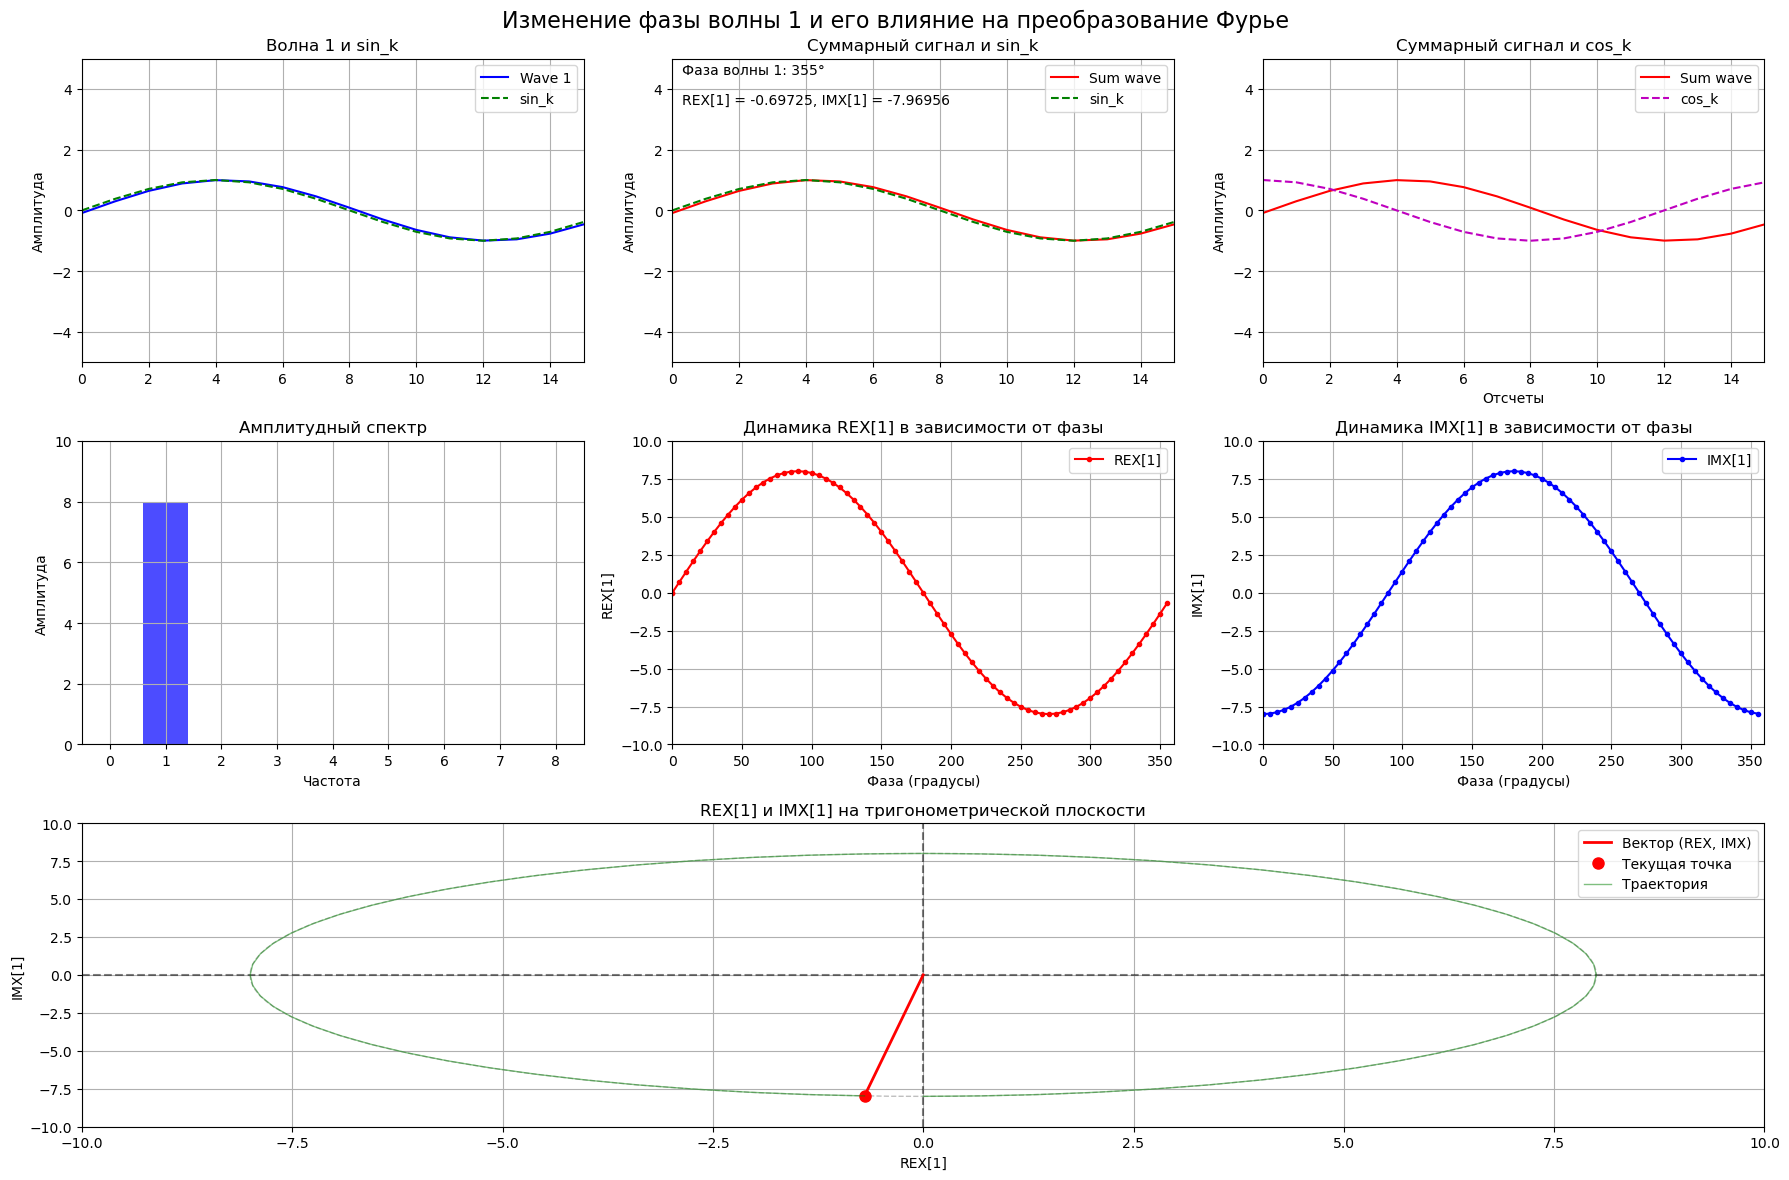

Фаза: 45°, REX[1] = 5.65685, IMX[1] = -5.65685


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import matplotlib.animation as animation

# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 16  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 2.0  # Амплитуда дополнительной волны 2
W3_A = 3.0  # Амплитуда дополнительной волны 3
W4_A = 4.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 45   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0 # Дополнительная волна 4

# Выбранная частота для анализа
F_b = 1

# ----------------------------
# ФУНКЦИЯ ДЛА ВЫЧИСЛЕНИЙ
# ----------------------------

def compute_signals(phase_deg):
    # Конвертация фаз из градусов в радианы
    W1_P_RAD = phase_deg * np.pi / 180
    W2_P_RAD = W2_P_DEG * np.pi / 180
    W3_P_RAD = W3_P_DEG * np.pi / 180
    W4_P_RAD = W4_P_DEG * np.pi / 180

    # Генерация волн
    wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
    wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
    wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
    wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

    # Сумма сигналов
    sum_wave = wave_1 + wave_2 + wave_3 + wave_4

    # DFT (прямое преобразование Фурье)
    REX = np.zeros(N // 2 + 1)
    IMX = np.zeros(N // 2 + 1)
    sin_k = np.zeros(N)
    cos_k = np.zeros(N)

    # Переменная для хранения значений REX[K] для выбранного F_b
    rex_values = []
    
    for K in range(N // 2 + 1):
        for I in range(N):
            angle = 2 * np.pi * K * I / N
            REX[K] += sum_wave[I] * np.cos(angle)
            IMX[K] -= sum_wave[I] * np.sin(angle)

            if K == F_b:
                cos_k[I] = np.cos(angle)
                sin_k[I] = np.sin(angle)
                rex_values.append(REX[K])  # Сохраняем текущее значение REX[K]
                
                # Вывод информации о вычислениях
                if I == N-1:  # Выводим только для последнего отсчета
                    print(f"Фаза: {phase_deg}°, REX[{F_b}] = {REX[F_b]:.5f}, IMX[{F_b}] = {IMX[F_b]:.5f}")

    # Амплитудный спектр
    amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
    
    return wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, REX[F_b], IMX[F_b]

# ----------------------------
# ПОДГОТОВКА ДАННЫХ ДЛЯ АНИМАЦИИ
# ----------------------------

# Создаем массив отсчетов
N_i = np.arange(N)
N_i_half = np.arange(N // 2 + 1)

# Создаем фигуру для анимации с дополнительным графиком
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, :])

fig.suptitle('Изменение фазы волны 1 и его влияние на преобразование Фурье', fontsize=16)

# Настраиваем оси для первых трех графиков
for ax in [ax1, ax2, ax3]:
    ax.grid(True)
    ax.set_xlim(0, N-1)
    ax.set_ylim(-5, 5)

ax1.set_ylabel('Амплитуда')
ax1.set_title('Волна 1 и sin_k')

ax2.set_ylabel('Амплитуда')
ax2.set_title('Суммарный сигнал и sin_k')

ax3.set_ylabel('Амплитуда')
ax3.set_xlabel('Отсчеты')
ax3.set_title('Суммарный сигнал и cos_k')

# Настраиваем ось для спектра
ax4.grid(True)
ax4.set_xlim(-0.5, len(N_i_half)-0.5)
ax4.set_ylim(0, 10)
ax4.set_ylabel('Амплитуда')
ax4.set_xlabel('Частота')
ax4.set_title('Амплитудный спектр')

# Настраиваем ось для графика REX[1]
ax5.grid(True)
ax5.set_xlim(0, 360)
ax5.set_ylim(-10, 10)
ax5.set_ylabel('REX[1]')
ax5.set_xlabel('Фаза (градусы)')
ax5.set_title('Динамика REX[1] в зависимости от фазы')

# Настраиваем ось для графика IMX[1]
ax6.grid(True)
ax6.set_xlim(0, 360)
ax6.set_ylim(-10, 10)
ax6.set_ylabel('IMX[1]')
ax6.set_xlabel('Фаза (градусы)')
ax6.set_title('Динамика IMX[1] в зависимости от фазы')

# Настраиваем ось для тригонометрической плоскости
ax7.grid(True)
ax7.set_xlim(-10, 10)
ax7.set_ylim(-10, 10)
ax7.set_xlabel('REX[1]')
ax7.set_ylabel('IMX[1]')
ax7.set_title('REX[1] и IMX[1] на тригонометрической плоскости')
ax7.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax7.axvline(x=0, color='k', linestyle='--', alpha=0.5)

# Добавляем единичную окружность
circle = plt.Circle((0, 0), 8, fill=False, color='gray', linestyle='--', alpha=0.5)
ax7.add_patch(circle)

# Создаем пустые графики
line1, = ax1.plot([], [], 'b-', label='Wave 1')
line1_sin, = ax1.plot([], [], 'g--', label='sin_k')
line2, = ax2.plot([], [], 'r-', label='Sum wave')
line2_sin, = ax2.plot([], [], 'g--', label='sin_k')
line3, = ax3.plot([], [], 'r-', label='Sum wave')
line3_cos, = ax3.plot([], [], 'm--', label='cos_k')

# Для спектра создаем пустой bar-plot вместо stem-plot
bars = ax4.bar(N_i_half, np.zeros_like(N_i_half), width=0.8, color='blue', alpha=0.7)

# Для графиков REX[1] и IMX[1] создаем пустые линии
line_rex, = ax5.plot([], [], 'ro-', label='REX[1]', markersize=3)
line_imx, = ax6.plot([], [], 'bo-', label='IMX[1]', markersize=3)

# Для тригонометрической плоскости создаем вектор и траекторию
vector, = ax7.plot([], [], 'r-', linewidth=2)
point, = ax7.plot([], [], 'ro', markersize=8)
trajectory, = ax7.plot([], [], 'g-', alpha=0.5, linewidth=1)

# Добавляем легенды
ax1.legend()
ax2.legend()
ax3.legend()
ax5.legend()
ax6.legend()
ax7.legend([vector, point, trajectory], ['Вектор (REX, IMX)', 'Текущая точка', 'Траектория'])

# Добавляем текст для отображения фазы и значения REX[K]
phase_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes)
rex_text = ax2.text(0.02, 0.85, '', transform=ax2.transAxes)

# Списки для хранения истории значений
phases_history = []
rex_history = []
imx_history = []
trajectory_x = []
trajectory_y = []

# ----------------------------
# ФУНКЦИЯ АНИМАЦИИ
# ----------------------------

def animate(phase_idx):
    # Вычисляем текущую фазу (от 0 до 360 градусов с шагом 5)
    phase_deg = phase_idx * 5
    
    # Вычисляем сигналы для текущей фазы
    wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb, imx_fb = compute_signals(phase_deg)
    
    # Сохраняем текущие значения для истории
    phases_history.append(phase_deg)
    rex_history.append(rex_fb)
    imx_history.append(imx_fb)
    trajectory_x.append(rex_fb)
    trajectory_y.append(imx_fb)
    
    # Обновляем графики
    line1.set_data(N_i, wave_1)
    line1_sin.set_data(N_i, sin_k)
    line2.set_data(N_i, sum_wave)
    line2_sin.set_data(N_i, sin_k)
    line3.set_data(N_i, sum_wave)
    line3_cos.set_data(N_i, cos_k)
    
    # Обновляем спектр (bar-plot)
    for i, bar in enumerate(bars):
        if i < len(amplitude_spectrum):
            bar.set_height(amplitude_spectrum[i])
        else:
            bar.set_height(0)
    
    # Обновляем графики REX[1] и IMX[1]
    line_rex.set_data(phases_history, rex_history)
    line_imx.set_data(phases_history, imx_history)
    
    # Обновляем тригонометрическую плоскость
    vector.set_data([0, rex_fb], [0, imx_fb])
    point.set_data([rex_fb], [imx_fb])
    trajectory.set_data(trajectory_x, trajectory_y)
    
    # Автоматически масштабируем оси для графиков REX[1] и IMX[1]
    ax5.relim()
    ax5.autoscale_view()
    ax6.relim()
    ax6.autoscale_view()
    
    # Обновляем текст
    phase_text.set_text(f'Фаза волны 1: {phase_deg}°')
    rex_text.set_text(f'REX[{F_b}] = {rex_fb:.5f}, IMX[{F_b}] = {imx_fb:.5f}')
    
    return (line1, line1_sin, line2, line2_sin, line3, line3_cos, bars, 
            line_rex, line_imx, vector, point, trajectory, phase_text, rex_text)

# ----------------------------
# СОЗДАНИЕ АНИМАЦИИ
# ----------------------------

# Создаем анимацию (72 кадра - 360 градусов / 5 градусов)
ani = FuncAnimation(fig, animate, frames=72, interval=100, blit=False, repeat=False)

# Сохраняем анимацию как GIF
ani.save('phase_animation.gif', writer='pillow', fps=1)

plt.tight_layout()
plt.show()

# ----------------------------
# ВЫВОД СТАТИЧЕСКИХ ГРАФИКОВ ДЛЯ ТЕКУЩЕЙ ФАЗЫ
# ----------------------------

# Вычисляем сигналы для начальной фазы
wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb, imx_fb = compute_signals(W1_P_DEG)

# Создаем графики с помощью Bokeh
p = figure(title="Суммарный сигнал и sin_k", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")
p.line(N_i, np.zeros(N), line_color="black")
show(p)

p2 = figure(title="Суммарный сигнал и cos_k", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p2.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p2.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")
p2.scatter(N_i, cos_k, size=7, marker="square", legend_label="cos_k", line_color="green", fill_alpha=0.3)
p2.line(N_i, cos_k, legend_label="cos_k", line_color="green")
p2.line(N_i, np.zeros(N), line_color="black")
show(p2)

amp_plot = figure(title="Амплитудный спектр", x_axis_label='Частота', y_axis_label='Амплитуда')
X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")
amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0=N_i_half, y0=X_axis, x1=N_i_half, y1=amplitude_spectrum, color="navy", alpha=0.6, line_width=2)
show(amp_plot)

# График для wave_1 с sin_k
p_wave1 = figure(title="Wave_1 и sin_k", width=1000, height=400,
                x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p_wave1.scatter(N_i, wave_1, size=8, color="blue", alpha=0.7, legend_label="wave_1")
p_wave1.line(N_i, wave_1, line_color="blue", line_width=2)
p_wave1.scatter(N_i, sin_k, size=8, color="green", alpha=0.7, legend_label="sin_k")
p_wave1.line(N_i, sin_k, line_color="green", line_width=2)
p_wave1.line(N_i, np.zeros(N), line_color="black")
show(p_wave1)

# Создаем график для тригонометрической плоскости с помощью Bokeh
trig_plot = figure(title="REX[1] и IMX[1] на тригонометрической плоскости", 
                  x_axis_label='REX[1]', y_axis_label='IMX[1]',
                  width=500, height=500)
trig_plot.circle([0], [0], size=5, color="black")
trig_plot.line([-10, 10], [0, 0], line_color="black", line_dash="dashed", alpha=0.5)
trig_plot.line([0, 0], [-10, 10], line_color="black", line_dash="dashed", alpha=0.5)

# Добавляем единичную окружность
angles = np.linspace(0, 2*np.pi, 100)
trig_plot.line(8*np.cos(angles), 8*np.sin(angles), line_color="gray", line_dash="dashed", alpha=0.5)

# Добавляем вектор и точку
trig_plot.line([0, rex_fb], [0, imx_fb], line_color="red", line_width=2)
trig_plot.circle([rex_fb], [imx_fb], size=10, color="red")

show(trig_plot)

Loading BokehJS ...

Фаза: 0°, REX[1] = 0.00000, IMX[1] = -8.00000
Фаза: 0°, REX[1] = 0.00000, IMX[1] = -8.00000
Фаза: 5°, REX[1] = 0.69725, IMX[1] = -7.96956
Фаза: 10°, REX[1] = 1.38919, IMX[1] = -7.87846
Фаза: 15°, REX[1] = 2.07055, IMX[1] = -7.72741
Фаза: 20°, REX[1] = 2.73616, IMX[1] = -7.51754
Фаза: 25°, REX[1] = 3.38095, IMX[1] = -7.25046
Фаза: 30°, REX[1] = 4.00000, IMX[1] = -6.92820
Фаза: 35°, REX[1] = 4.58861, IMX[1] = -6.55322
Фаза: 40°, REX[1] = 5.14230, IMX[1] = -6.12836
Фаза: 45°, REX[1] = 5.65685, IMX[1] = -5.65685
Фаза: 50°, REX[1] = 6.12836, IMX[1] = -5.14230
Фаза: 55°, REX[1] = 6.55322, IMX[1] = -4.58861
Фаза: 60°, REX[1] = 6.92820, IMX[1] = -4.00000
Фаза: 65°, REX[1] = 7.25046, IMX[1] = -3.38095
Фаза: 70°, REX[1] = 7.51754, IMX[1] = -2.73616
Фаза: 75°, REX[1] = 7.72741, IMX[1] = -2.07055
Фаза: 80°, REX[1] = 7.87846, IMX[1] = -1.38919
Фаза: 85°, REX[1] = 7.96956, IMX[1] = -0.69725
Фаза: 90°, REX[1] = 8.00000, IMX[1] = -0.00000
Фаза: 95°, REX[1] = 7.96956, IMX[1] = 0.69725
Фаза: 100°, REX[1

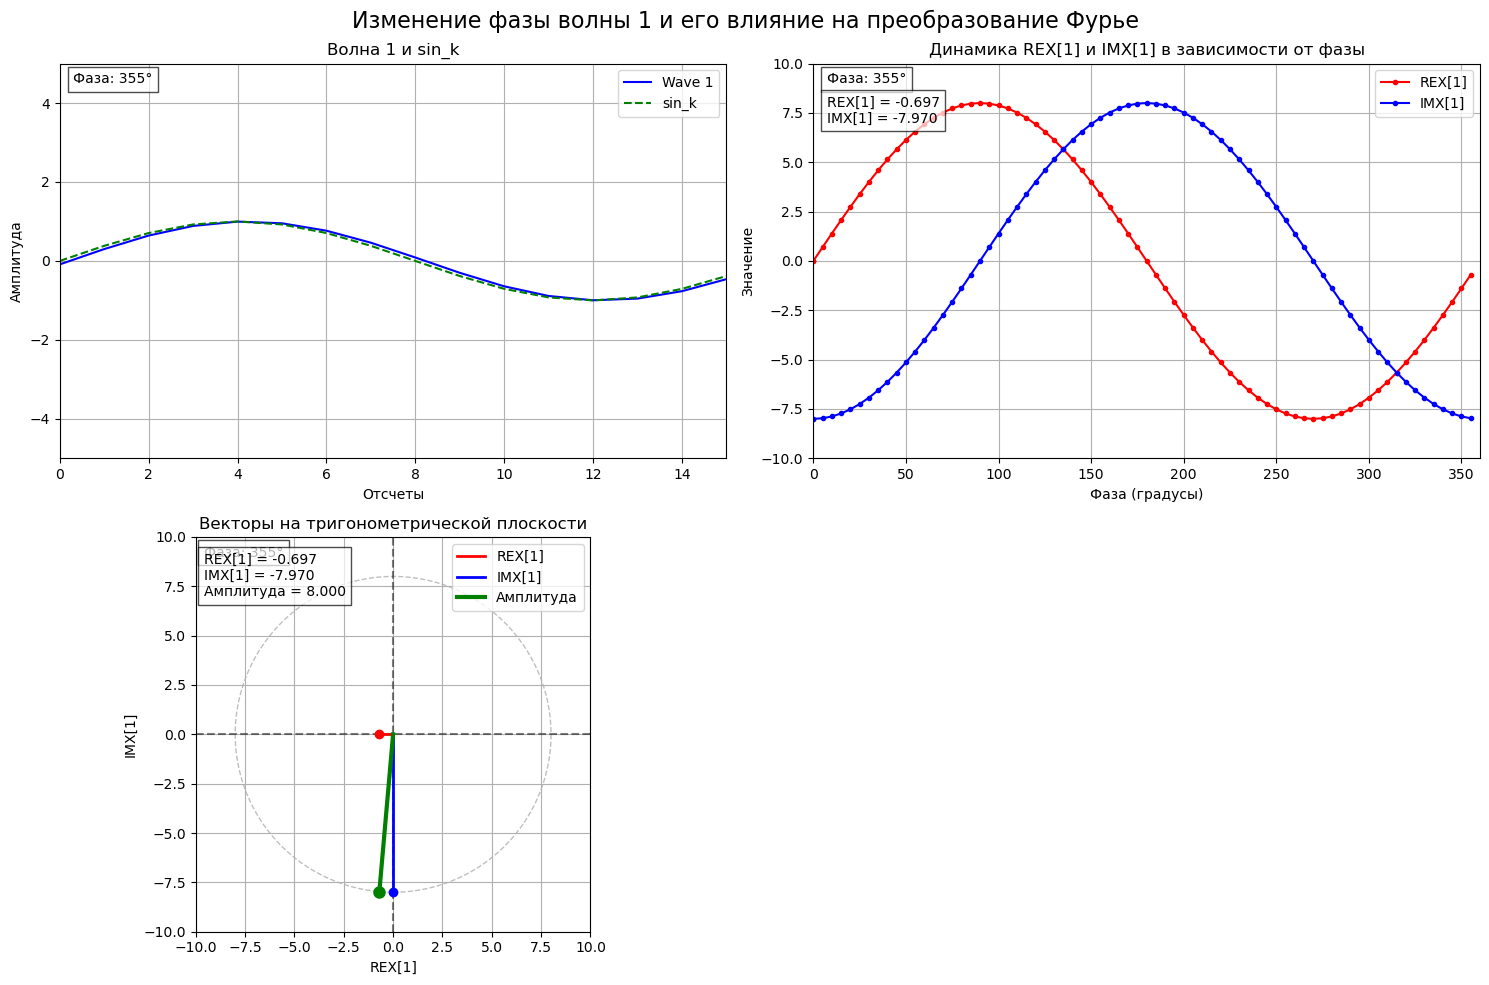

Фаза: 45°, REX[1] = 5.65685, IMX[1] = -5.65685


Фаза: 0.0°, REX[1] = 0.00000, IMX[1] = -8.00000
Фаза: 5.070422535211268°, REX[1] = 0.70704, IMX[1] = -7.96869
Фаза: 10.140845070422536°, REX[1] = 1.40855, IMX[1] = -7.87502
Фаза: 15.211267605633804°, REX[1] = 2.09903, IMX[1] = -7.71972
Фаза: 20.281690140845072°, REX[1] = 2.77309, IMX[1] = -7.50400
Фаза: 25.35211267605634°, REX[1] = 3.42544, IMX[1] = -7.22955
Фаза: 30.422535211267608°, REX[1] = 4.05098, IMX[1] = -6.89852
Фаза: 35.49295774647888°, REX[1] = 4.64482, IMX[1] = -6.51350
Фаза: 40.563380281690144°, REX[1] = 5.20231, IMX[1] = -6.07750
Фаза: 45.63380281690141°, REX[1] = 5.71908, IMX[1] = -5.59393
Фаза: 50.70422535211268°, REX[1] = 6.19110, IMX[1] = -5.06659
Фаза: 55.77464788732395°, REX[1] = 6.61465, IMX[1] = -4.49959
Фаза: 60.845070422535215°, REX[1] = 6.98644, IMX[1] = -3.89738
Фаза: 65.91549295774648°, REX[1] = 7.30356, IMX[1] = -3.26467
Фаза: 70.98591549295776°, REX[1] = 7.56351, IMX[1] = -2.60640
Фаза: 76.05633802816902°, REX[1] = 7.76427, IMX[1] = -1.92774
Фаза: 81.1267605

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
import matplotlib.animation as animation

# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 16  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 2.0  # Амплитуда дополнительной волны 2
W3_A = 3.0  # Амплитуда дополнительной волны 3
W4_A = 4.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 45   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 0  # Дополнительная волна 2
W3_K = 0  # Дополнительная волна 3
W4_K = 0 # Дополнительная волна 4

# Выбранная частота для анализа
F_b = 1

# ----------------------------
# ФУНКЦИЯ ДЛЯ ВЫЧИСЛЕНИЙ
# ----------------------------

def compute_signals(phase_deg):
    # Конвертация фаз из градусов в радианы
    W1_P_RAD = phase_deg * np.pi / 180
    W2_P_RAD = W2_P_DEG * np.pi / 180
    W3_P_RAD = W3_P_DEG * np.pi / 180
    W4_P_RAD = W4_P_DEG * np.pi / 180

    # Генерация волн
    wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
    wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
    wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
    wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

    # Сумма сигналов
    sum_wave = wave_1 + wave_2 + wave_3 + wave_4

    # DFT (прямое преобразование Фурье)
    REX = np.zeros(N // 2 + 1)
    IMX = np.zeros(N // 2 + 1)
    sin_k = np.zeros(N)
    cos_k = np.zeros(N)

    # Переменная для хранения значений REX[K] для выбранного F_b
    rex_values = []
    
    for K in range(N // 2 + 1):
        for I in range(N):
            angle = 2 * np.pi * K * I / N
            REX[K] += sum_wave[I] * np.cos(angle)
            IMX[K] -= sum_wave[I] * np.sin(angle)

            if K == F_b:
                cos_k[I] = np.cos(angle)
                sin_k[I] = np.sin(angle)
                rex_values.append(REX[K])  # Сохраняем текущее значение REX[K]
                
                # Вывод информации о вычислениях
                if I == N-1:  # Выводим только для последнего отсчета
                    print(f"Фаза: {phase_deg}°, REX[{F_b}] = {REX[F_b]:.5f}, IMX[{F_b}] = {IMX[F_b]:.5f}")

    # Амплитудный спектр
    amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
    
    return wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, REX[F_b], IMX[F_b]

# ----------------------------
# ПОДГОТОВКА ДАННЫХ ДЛЯ АНИМАЦИИ
# ----------------------------

# Создаем массив отсчетов
N_i = np.arange(N)
N_i_half = np.arange(N // 2 + 1)

# Создаем фигуру для анимации с новой структурой
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])  # Волна 1 и sin_k
ax2 = fig.add_subplot(gs[0, 1])  # Объединенный график REX[1] и IMX[1]
ax3 = fig.add_subplot(gs[1, 0])  # Тригонометрическая плоскость
ax4 = fig.add_subplot(gs[1, 1])  # Запасной график (можно использовать для других целей)

fig.suptitle('Изменение фазы волны 1 и его влияние на преобразование Фурье', fontsize=16)

# Настраиваем ось для волны 1 и sin_k
ax1.grid(True)
ax1.set_xlim(0, N-1)
ax1.set_ylim(-5, 5)
ax1.set_ylabel('Амплитуда')
ax1.set_xlabel('Отсчеты')
ax1.set_title('Волна 1 и sin_k')

# Настраиваем ось для объединенного графика REX[1] и IMX[1]
ax2.grid(True)
ax2.set_xlim(0, 360)
ax2.set_ylim(-10, 10)
ax2.set_ylabel('Значение')
ax2.set_xlabel('Фаза (градусы)')
ax2.set_title('Динамика REX[1] и IMX[1] в зависимости от фазы')

# Настраиваем ось для тригонометрической плоскости
ax3.grid(True)
max_amplitude = 10  # Максимальная амплитуда для круглой плоскости
ax3.set_xlim(-max_amplitude, max_amplitude)
ax3.set_ylim(-max_amplitude, max_amplitude)
ax3.set_xlabel('REX[1]')
ax3.set_ylabel('IMX[1]')
ax3.set_title('Векторы на тригонометрической плоскости')
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax3.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax3.set_aspect('equal')  # Делаем плоскость круглой

# Добавляем единичную окружность
circle = plt.Circle((0, 0), 8, fill=False, color='gray', linestyle='--', alpha=0.5)
ax3.add_patch(circle)

# Скрываем запасной график
ax4.axis('off')

# Создаем пустые графики
line1, = ax1.plot([], [], 'b-', label='Wave 1')
line1_sin, = ax1.plot([], [], 'g--', label='sin_k')

# Для объединенного графика REX[1] и IMX[1]
line_rex, = ax2.plot([], [], 'ro-', label='REX[1]', markersize=3)
line_imx, = ax2.plot([], [], 'bo-', label='IMX[1]', markersize=3)

# Для тригонометрической плоскости создаем три вектора
vector_rex, = ax3.plot([], [], 'r-', linewidth=2, label='REX[1]')
vector_imx, = ax3.plot([], [], 'b-', linewidth=2, label='IMX[1]')
vector_amp, = ax3.plot([], [], 'g-', linewidth=3, label='Амплитуда')

# Добавляем точки на концах векторов
point_rex, = ax3.plot([], [], 'ro', markersize=6)
point_imx, = ax3.plot([], [], 'bo', markersize=6)
point_amp, = ax3.plot([], [], 'go', markersize=8)

# Добавляем легенды
ax1.legend()
ax2.legend()
ax3.legend()

# Добавляем текстовые окошки для отображения угла смещения на всех графиках
phase_text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.7))
phase_text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.7))
phase_text3 = ax3.text(0.02, 0.95, '', transform=ax3.transAxes, bbox=dict(facecolor='white', alpha=0.7))

# Добавляем текстовые окошки для отображения значений REX[1] и IMX[1]
values_text2 = ax2.text(0.02, 0.85, '', transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.7))
values_text3 = ax3.text(0.02, 0.85, '', transform=ax3.transAxes, bbox=dict(facecolor='white', alpha=0.7))

# Списки для хранения истории значений
phases_history = []
rex_history = []
imx_history = []

# ----------------------------
# ФУНКЦИЯ АНИМАЦИИ
# ----------------------------

def animate(phase_idx):
    # Вычисляем текущую фазу (от 0 до 360 градусов с шагом 5)
    phase_deg = phase_idx * 5
    
    # Вычисляем сигналы для текущей фазы
    wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb, imx_fb = compute_signals(phase_deg)
    
    # Сохраняем текущие значения для истории
    phases_history.append(phase_deg)
    rex_history.append(rex_fb)
    imx_history.append(imx_fb)
    
    # Обновляем графики
    line1.set_data(N_i, wave_1)
    line1_sin.set_data(N_i, sin_k)
    
    # Обновляем объединенный график REX[1] и IMX[1]
    line_rex.set_data(phases_history, rex_history)
    line_imx.set_data(phases_history, imx_history)
    
    # Обновляем тригонометрическую плоскость
    # Вектор REX[1] (по оси X)
    vector_rex.set_data([0, rex_fb], [0, 0])
    point_rex.set_data([rex_fb], [0])
    
    # Вектор IMX[1] (по оси Y)
    vector_imx.set_data([0, 0], [0, imx_fb])
    point_imx.set_data([0], [imx_fb])
    
    # Результирующий вектор (амплитуда)
    vector_amp.set_data([0, rex_fb], [0, imx_fb])
    point_amp.set_data([rex_fb], [imx_fb])
    
    # Автоматически масштабируем оси для объединенного графика
    ax2.relim()
    ax2.autoscale_view()
    
    # Обновляем текстовые окошки
    phase_text1.set_text(f'Фаза: {phase_deg}°')
    phase_text2.set_text(f'Фаза: {phase_deg}°')
    phase_text3.set_text(f'Фаза: {phase_deg}°')
    
    values_text2.set_text(f'REX[1] = {rex_fb:.3f}\nIMX[1] = {imx_fb:.3f}')
    values_text3.set_text(f'REX[1] = {rex_fb:.3f}\nIMX[1] = {imx_fb:.3f}\nАмплитуда = {amplitude_spectrum[F_b]:.3f}')
    
    return (line1, line1_sin, line_rex, line_imx, 
            vector_rex, vector_imx, vector_amp, 
            point_rex, point_imx, point_amp,
            phase_text1, phase_text2, phase_text3, values_text2, values_text3)

# ----------------------------
# СОЗДАНИЕ АНИМАЦИИ
# ----------------------------

# Создаем анимацию (72 кадра - 360 градусов / 5 градусов)
ani = FuncAnimation(fig, animate, frames=72, interval=100, blit=False, repeat=False)

# Сохраняем анимацию как GIF
ani.save('phase_animation.gif', writer='pillow', fps=1)

plt.tight_layout()
plt.show()

# ----------------------------
# ВЫВОД СТАТИЧЕСКИХ ГРАФИКОВ ДЛЯ ТЕКУЩЕЙ ФАЗЫ
# ----------------------------

# Вычисляем сигналы для начальной фазы
wave_1, wave_2, sum_wave, sin_k, cos_k, amplitude_spectrum, rex_values, rex_fb, imx_fb = compute_signals(W1_P_DEG)

# Создаем графики с помощью Bokeh
p = figure(title="Волна 1 и sin_k", x_axis_label='Отсчеты', y_axis_label='Амплитуда')
p.scatter(N_i, wave_1, size=7, marker="circle", legend_label="wave_1", line_color="blue", fill_alpha=0.3)
p.line(N_i, wave_1, legend_label="wave_1", line_color="blue")
p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")
p.line(N_i, np.zeros(N), line_color="black")
show(p)

# График для объединенного отображения REX[1] и IMX[1]
p_combined = figure(title="Динамика REX[1] и IMX[1]", x_axis_label='Фаза (градусы)', y_axis_label='Значение')
phases = np.linspace(0, 360, 72)
p_combined.line(phases, np.zeros_like(phases), line_color="black", line_dash="dashed", alpha=0.5)

# Вычисляем значения для всех фаз
rex_all = []
imx_all = []
for phase in phases:
    _, _, _, _, _, _, _, rex, imx = compute_signals(phase)
    rex_all.append(rex)
    imx_all.append(imx)

p_combined.line(phases, rex_all, line_color="red", legend_label="REX[1]", line_width=2)
p_combined.line(phases, imx_all, line_color="blue", legend_label="IMX[1]", line_width=2)
show(p_combined)

# График для тригонометрической плоскости
trig_plot = figure(title="Векторы на тригонометрической плоскости", 
                  x_axis_label='REX[1]', y_axis_label='IMX[1]',
                  width=500, height=500)
trig_plot.circle([0], [0], size=5, color="black")
trig_plot.line([-max_amplitude, max_amplitude], [0, 0], line_color="black", line_dash="dashed", alpha=0.5)
trig_plot.line([0, 0], [-max_amplitude, max_amplitude], line_color="black", line_dash="dashed", alpha=0.5)

# Добавляем единичную окружность
angles = np.linspace(0, 2*np.pi, 100)
trig_plot.line(8*np.cos(angles), 8*np.sin(angles), line_color="gray", line_dash="dashed", alpha=0.5)

# Добавляем векторы
trig_plot.line([0, rex_fb], [0, 0], line_color="red", line_width=2, legend_label="REX[1]")
trig_plot.line([0, 0], [0, imx_fb], line_color="blue", line_width=2, legend_label="IMX[1]")
trig_plot.line([0, rex_fb], [0, imx_fb], line_color="green", line_width=3, legend_label="Амплитуда")

# Добавляем точки
trig_plot.circle([rex_fb], [0], size=8, color="red")
trig_plot.circle([0], [imx_fb], size=8, color="blue")
trig_plot.circle([rex_fb], [imx_fb], size=10, color="green")

show(trig_plot)